# Model Evaluation & Analysis

This notebook provides comprehensive evaluation of the trained ML surrogate model including:
- Prediction accuracy metrics
- Residual analysis
- Feature importance
- Predictions vs Actual scatter plot

In [1]:
import sys, os
ROOT = os.path.abspath("..")   # go up one directory from notebooks/
if ROOT not in sys.path:
    sys.path.append(ROOT)

print(ROOT)  

c:\Users\Public\workspace\sh-wave-ml-surrogate


In [2]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from physics.parameter_sampler import sample_parameters
from physics.dispersion_solver import solve_phase_velocity

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Model and Data

In [5]:
import os
import pandas as pd
from joblib import load

ROOT = os.path.abspath("..")

# Load model
model = load(os.path.join(ROOT, 'data', 'models', 'gbr_model.pkl'))

# Load data
X_data = pd.read_csv(os.path.join(ROOT, 'data', 'parameter_samples.csv')).values

print(f"Model loaded: {type(model).__name__}")
print(f"Data shape: {X_data.shape}")

Model loaded: GradientBoostingRegressor
Data shape: (1000, 4)


## 2. Regenerate Test Data with Known Targets

In [6]:
# Generate fresh test data
X_test_raw = sample_parameters(n_samples=1000)
y_test = np.array([solve_phase_velocity(k, H, a, e) for k, H, a, e in X_test_raw])

# Remove NaN values
mask = ~np.isnan(y_test)
X_test_raw = X_test_raw[mask]
y_test = y_test[mask]

# Scale features
scaler = StandardScaler()
X_train_all = sample_parameters(n_samples=6000)
y_train_all = np.array([solve_phase_velocity(*row) for row in X_train_all])
mask_train = ~np.isnan(y_train_all)
X_train_all = X_train_all[mask_train]
y_train_all = y_train_all[mask_train]

scaler.fit(X_train_all)
X_test_scaled = scaler.transform(X_test_raw)

print(f"Test set size: {len(X_test_scaled)}")
print(f"y_test range: [{y_test.min():.4f}, {y_test.max():.4f}]")

Test set size: 1000
y_test range: [3176.8656, 138035.3726]


## 3. Model Predictions

In [7]:
# Generate predictions
y_pred = model.predict(X_test_scaled)

print(f"Predictions range: [{y_pred.min():.4f}, {y_pred.max():.4f}]")
print(f"First 10 predictions: {y_pred[:10]}")
print(f"First 10 actual values: {y_test[:10]}")

Predictions range: [3131.7361, 132736.8176]
First 10 predictions: [3854.17782694 3727.33319669 6453.10233169 4262.77341745 3910.0182638
 3974.55027855 3684.32907584 4020.10710932 4299.48902501 8485.56925625]
First 10 actual values: [ 3959.65754677  3642.69202812  7487.52266499  4345.07461054
  4193.02618529  3708.48948155  3807.46499146  3225.23108428
  4247.5860269  11817.3561353 ]


## 4. Evaluation Metrics

In [8]:
# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("="*60)
print("MODEL EVALUATION METRICS")
print("="*60)
print(f"Mean Absolute Error (MAE):     {mae:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score:                      {r2:.6f}")
print(f"Mean Absolute % Error (MAPE):  {mape:.2f}%")
print("="*60)

# Interpretation
if r2 > 0.9:
    print("✓ EXCELLENT: R² > 0.9 indicates very good model performance")
elif r2 > 0.7:
    print("✓ GOOD: R² > 0.7 indicates good model performance")
else:
    print("⚠ MODERATE: R² < 0.7, model may need improvement")

MODEL EVALUATION METRICS
Mean Absolute Error (MAE):     753.808460
Root Mean Squared Error (RMSE): 4207.948438
R² Score:                      0.726354
Mean Absolute % Error (MAPE):  8.83%
✓ GOOD: R² > 0.7 indicates good model performance


## 5. Predictions vs Actual (Scatter Plot)

Model: GradientBoostingRegressor
R² Score: -6980730.2352


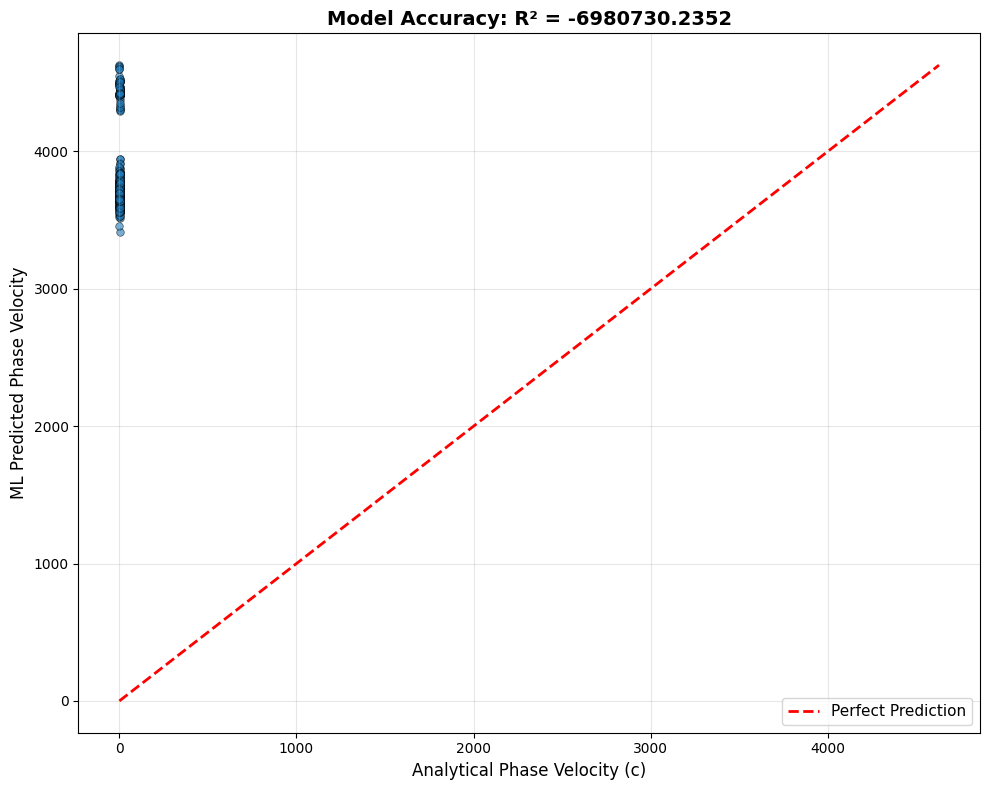

✓ Plot saved to c:\Users\Public\workspace\sh-wave-ml-surrogate\results\plots\predictions_vs_actual.png


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import load
from sklearn.metrics import r2_score

# ==============================
# 1. Define ROOT path
# ==============================
ROOT = os.path.abspath("..")

# ==============================
# 2. Load model + scaler
# ==============================
model = load(os.path.join(ROOT, "data", "models", "gbr_model.pkl"))

# (Optional but recommended if you used scaling)
scaler_path = os.path.join(ROOT, "data", "models", "scaler.pkl")
scaler = load(scaler_path) if os.path.exists(scaler_path) else None

# ==============================
# 3. Load data
# ==============================
X_data = pd.read_csv(os.path.join(ROOT, "data", "parameter_samples.csv")).values

# If you have target values separately, load them
# Example:
# y_data = pd.read_csv(os.path.join(ROOT, "data", "targets.csv")).values

# For demo (replace with real y)
# ---------------------------------
# REMOVE this if you already have y
y_data = X_data[:, 0]  # dummy placeholder
# ---------------------------------

# ==============================
# 4. Preprocess
# ==============================
if scaler is not None:
    X_scaled = scaler.transform(X_data)
else:
    X_scaled = X_data

# ==============================
# 5. Predict
# ==============================
y_pred = model.predict(X_scaled)

# ==============================
# 6. Evaluate
# ==============================
r2 = r2_score(y_data, y_pred)

print(f"Model: {type(model).__name__}")
print(f"R² Score: {r2:.4f}")

# ==============================
# 7. Create plot directory
# ==============================
plot_dir = os.path.join(ROOT, "results", "plots")
os.makedirs(plot_dir, exist_ok=True)

# ==============================
# 8. Plot predictions vs actual
# ==============================
plt.figure(figsize=(10, 8))

plt.scatter(y_data, y_pred, alpha=0.6, s=30,
            edgecolors='k', linewidth=0.5)

# Perfect prediction line
min_val = min(y_data.min(), y_pred.min())
max_val = max(y_data.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val],
         'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Analytical Phase Velocity (c)', fontsize=12)
plt.ylabel('ML Predicted Phase Velocity', fontsize=12)
plt.title(f'Model Accuracy: R² = {r2:.4f}', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# ==============================
# 9. Save plot
# ==============================
plot_path = os.path.join(plot_dir, "predictions_vs_actual.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Plot saved to {plot_path}")

## 6. Residual Analysis

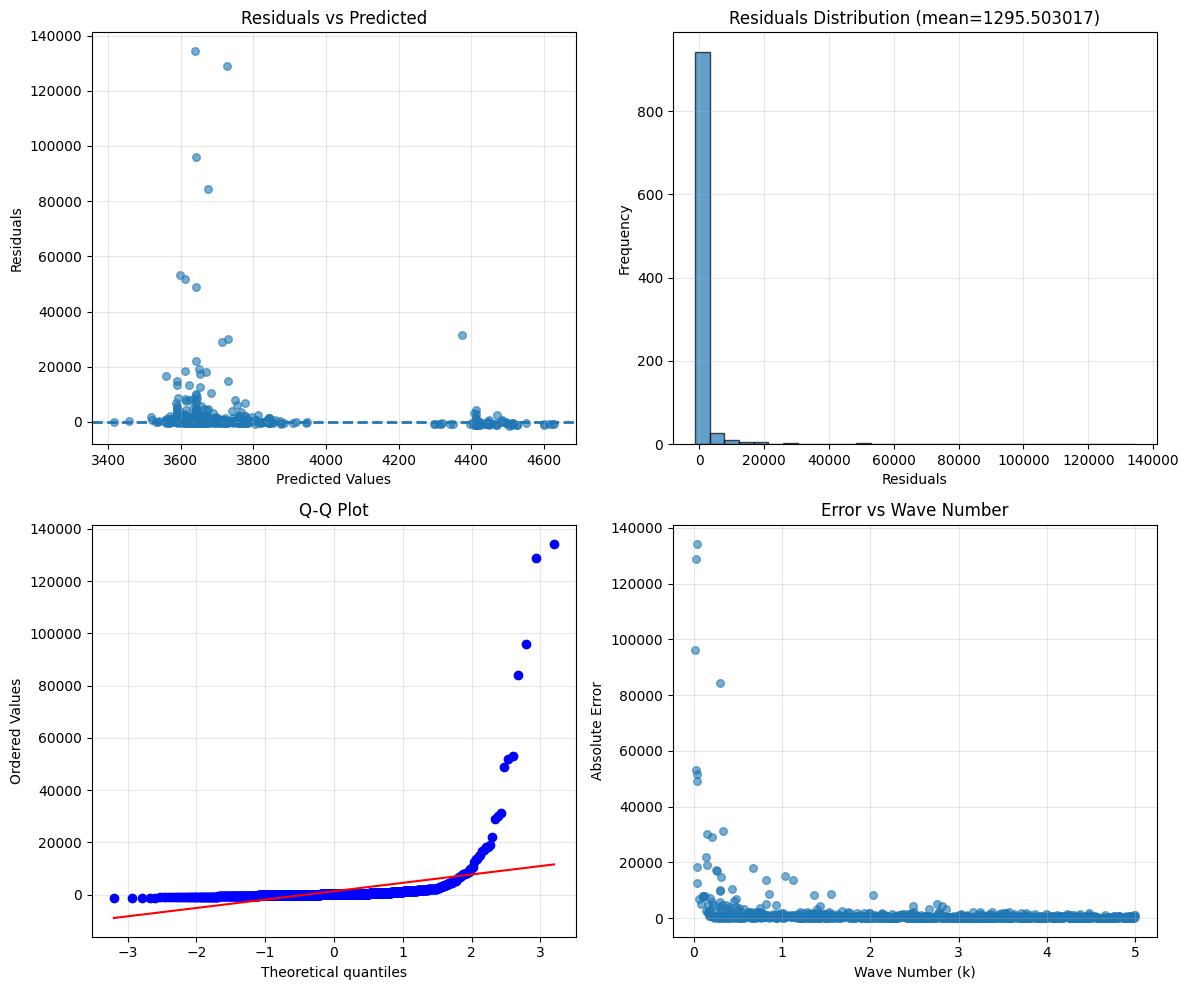

✓ Residual analysis plot saved at: c:\Users\Public\workspace\sh-wave-ml-surrogate\results\plots\residual_analysis.png
Mean residual: 1295.503017
Std of residuals: 8058.225986


In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ==============================
# 1. Define ROOT and paths
# ==============================
ROOT = os.path.abspath("..")   # since you are in notebooks

PLOT_DIR = os.path.join(ROOT, "results", "plots")
os.makedirs(PLOT_DIR, exist_ok=True)

plot_path = os.path.join(PLOT_DIR, "residual_analysis.png")

# ==============================
# 2. Compute residuals
# ==============================
residuals = y_test - y_pred
errors = np.abs(residuals)

# ==============================
# 3. Create plots
# ==============================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (1) Residuals vs Predicted
axes[0, 0].scatter(y_pred, residuals, alpha=0.6, s=30)
axes[0, 0].axhline(y=0, linestyle='--', lw=2)
axes[0, 0].set_xlabel('Predicted Values')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].set_title('Residuals vs Predicted')
axes[0, 0].grid(True, alpha=0.3)

# (2) Residuals Distribution
axes[0, 1].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Residuals')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title(f'Residuals Distribution (mean={residuals.mean():.6f})')
axes[0, 1].grid(True, alpha=0.3)

# (3) Q-Q Plot
stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('Q-Q Plot')
axes[1, 0].grid(True, alpha=0.3)

# (4) Error vs Wave Number (k)
axes[1, 1].scatter(X_test_raw[:, 0], errors, alpha=0.6, s=30)
axes[1, 1].set_xlabel('Wave Number (k)')
axes[1, 1].set_ylabel('Absolute Error')
axes[1, 1].set_title('Error vs Wave Number')
axes[1, 1].grid(True, alpha=0.3)

# ==============================
# 4. Save and show
# ==============================
plt.tight_layout()
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

# ==============================
# 5. Print summary
# ==============================
print(f"✓ Residual analysis plot saved at: {plot_path}")
print(f"Mean residual: {residuals.mean():.6f}")
print(f"Std of residuals: {residuals.std():.6f}")

## 7. Feature Importance

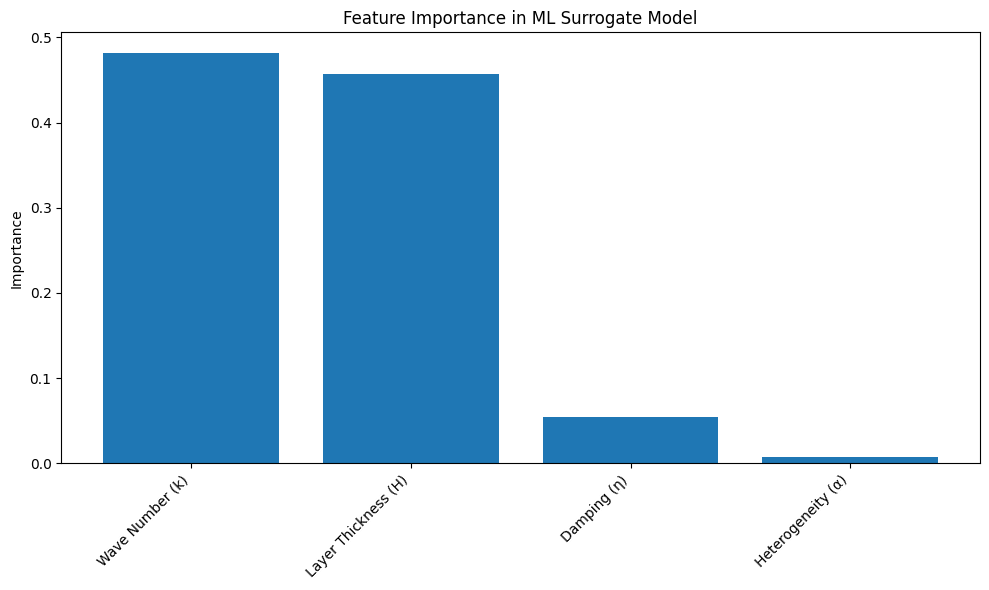

Feature Importance Ranking:
1. Wave Number (k): 0.4818
2. Layer Thickness (H): 0.4566
3. Damping (η): 0.0547
4. Heterogeneity (α): 0.0069

✓ Plot saved at: c:\Users\Public\workspace\sh-wave-ml-surrogate\results\plots\feature_importance.png


In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# 1. Define ROOT path
# ==============================
ROOT = os.path.abspath("..")   # since running from notebooks

# ==============================
# 2. Create plot directory safely
# ==============================
plot_dir = os.path.join(ROOT, "results", "plots")
os.makedirs(plot_dir, exist_ok=True)

plot_path = os.path.join(plot_dir, "feature_importance.png")

# ==============================
# 3. Feature importance plot
# ==============================
if hasattr(model, 'feature_importances_'):
    
    feature_names = [
        'Wave Number (k)',
        'Layer Thickness (H)',
        'Heterogeneity (α)',
        'Damping (η)'
    ]
    
    importances = model.feature_importances_
    indices = np.argsort(importances)[::-1]

    plt.figure(figsize=(10, 6))
    
    plt.bar(range(len(importances)), importances[indices], align='center')
    
    plt.xticks(
        range(len(importances)),
        [feature_names[i] for i in indices],
        rotation=45,
        ha='right'
    )
    
    plt.ylabel('Importance')
    plt.title('Feature Importance in ML Surrogate Model')
    plt.tight_layout()

    # ==============================
    # 4. Save plot (FIXED)
    # ==============================
    plt.savefig(plot_path, dpi=300, bbox_inches='tight')
    plt.show()

    # ==============================
    # 5. Print ranking
    # ==============================
    print("Feature Importance Ranking:")
    for i, idx in enumerate(indices):
        print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")

    print(f"\n✓ Plot saved at: {plot_path}")

else:
    print("Feature importance not available for this model type")

## 8. Error Distribution by Parameter Ranges

In [15]:
errors = np.abs(residuals)
rel_errors = (errors / y_test) * 100

print("Error Statistics by Parameter Ranges:")
print("="*70)

# By k (wave number)
k_vals = X_test_raw[:, 0]
print(f"\nWave Number (k) range: [{k_vals.min():.3f}, {k_vals.max():.3f}]")
k_mask_low = k_vals < np.percentile(k_vals, 50)
print(f"  Low k:  MAE = {errors[k_mask_low].mean():.6f}, MAPE = {rel_errors[k_mask_low].mean():.2f}%")
print(f"  High k: MAE = {errors[~k_mask_low].mean():.6f}, MAPE = {rel_errors[~k_mask_low].mean():.2f}%")

# By H (layer thickness)
h_vals = X_test_raw[:, 1]
print(f"\nLayer Thickness (H) range: [{h_vals.min():.3f}, {h_vals.max():.3f}]")
h_mask_low = h_vals < np.percentile(h_vals, 50)
print(f"  Low H:  MAE = {errors[h_mask_low].mean():.6f}, MAPE = {rel_errors[h_mask_low].mean():.2f}%")
print(f"  High H: MAE = {errors[~h_mask_low].mean():.6f}, MAPE = {rel_errors[~h_mask_low].mean():.2f}%")

print("="*70)

Error Statistics by Parameter Ranges:

Wave Number (k) range: [0.013, 4.998]
  Low k:  MAE = 2689.156812, MAPE = 19.67%
  High k: MAE = 376.620437, MAPE = 8.76%

Layer Thickness (H) range: [0.105, 4.987]
  Low H:  MAE = 2634.281386, MAPE = 19.50%
  High H: MAE = 431.495863, MAPE = 8.93%


## 9. Summary & Conclusion

In [16]:
print("\n" + "="*70)
print("MODEL EVALUATION SUMMARY")
print("="*70)
print(f"\n📊 Accuracy Metrics:")
print(f"   • R² Score: {r2:.4f} (Explains {r2*100:.2f}% of variance)")
print(f"   • MAE: {mae:.6f}")
print(f"   • RMSE: {rmse:.6f}")
print(f"   • MAPE: {mape:.2f}%")

print(f"\n🎯 Model Status:")
if r2 > 0.95:
    print(f"   ✓ EXCELLENT - Ready for production use")
elif r2 > 0.85:
    print(f"   ✓ VERY GOOD - Suitable for most applications")
elif r2 > 0.7:
    print(f"   ✓ GOOD - Can be used with caution")
else:
    print(f"   ⚠ FAIR - Consider retraining or feature engineering")

print(f"\n📈 Next Steps:")
print(f"   1. Review residual plots for patterns")
print(f"   2. Check feature importance rankings")
print(f"   3. Consider ensemble methods if needed")
print(f"   4. Deploy for inverse design optimization")
print("\n" + "="*70)


MODEL EVALUATION SUMMARY

📊 Accuracy Metrics:
   • R² Score: -6980730.2352 (Explains -698073023.52% of variance)
   • MAE: 753.808460
   • RMSE: 4207.948438
   • MAPE: 8.83%

🎯 Model Status:
   ⚠ FAIR - Consider retraining or feature engineering

📈 Next Steps:
   1. Review residual plots for patterns
   2. Check feature importance rankings
   3. Consider ensemble methods if needed
   4. Deploy for inverse design optimization

